## 1. Importación de paquetes y dataset

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_titanic = pd.read_csv("titanic_train.csv")
df_titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Cuando hay un patron HAY QUE HACER UNA GRÁFICA SIEMPRE! para explicarlo
Basado en la edad si sobrevivieron 


<Axes: xlabel='Survived', ylabel='count'>

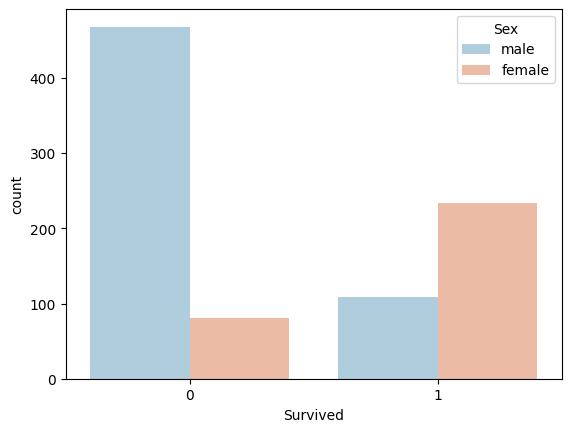

In [39]:
sns.countplot(x='Survived',hue='Sex',data=df_titanic,palette='RdBu_r')

Sobreviven más las mujeres que los hombres

----------

Basado en la clase de los pasajeros

<Axes: xlabel='Survived', ylabel='count'>

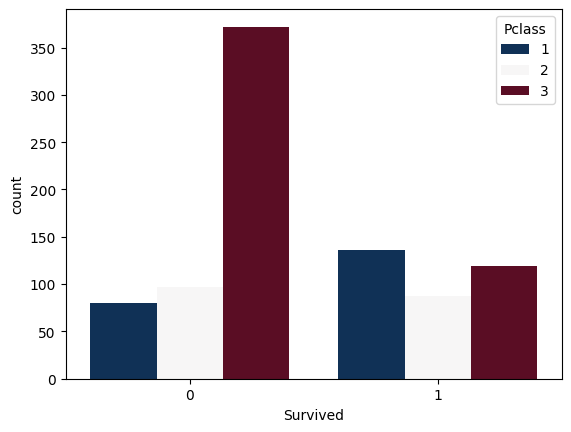

In [40]:
# fig, axes = plt.subplots(1,2, figsize=(10,6))

sns.countplot(x='Survived',hue='Pclass',data=df_titanic,palette='RdBu_r')


La clase 3 influye en que no sobrevivieran 

-----------

Histograma de la edad 

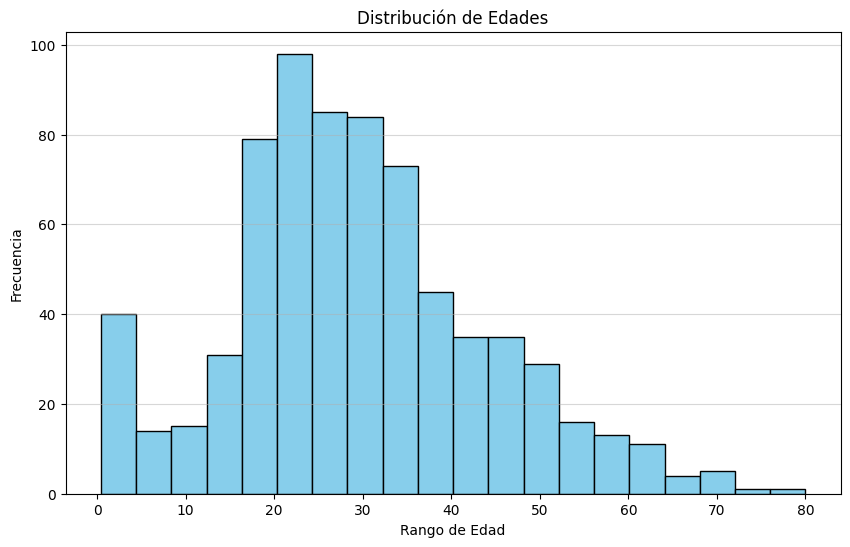

In [41]:
plt.figure(figsize=(10, 6))

df_titanic['Age'].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de Edades') 
plt.xlabel('Rango de Edad')

plt.ylabel('Frecuencia')

plt.grid(axis='y', alpha=0.5)

plt.show()

La distribución de edades demuestra que la mayoria tenían una edad entre 22 y 30 mayoritariamente 23 aprox

----------
Contrastado por la clase y la edad

/tmp/ipykernel_19981/1779968646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df_titanic, palette='winter')


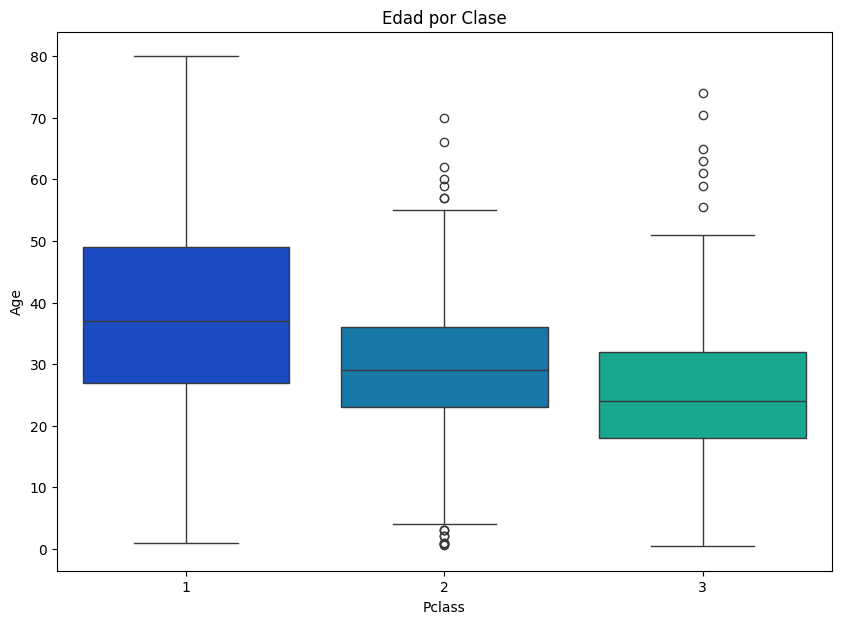

In [42]:

plt.figure(figsize=(10, 7))
sns.boxplot(x='Pclass', y='Age', data=df_titanic, palette='winter')
plt.title('Edad por Clase')
plt.show()

Clase 1: suele rondar los 37-38 años.

Clase 2 :ronda los 29 años.

Clase 3 :ronda los 24 años



-----------
otra forma de hacer las gráficas

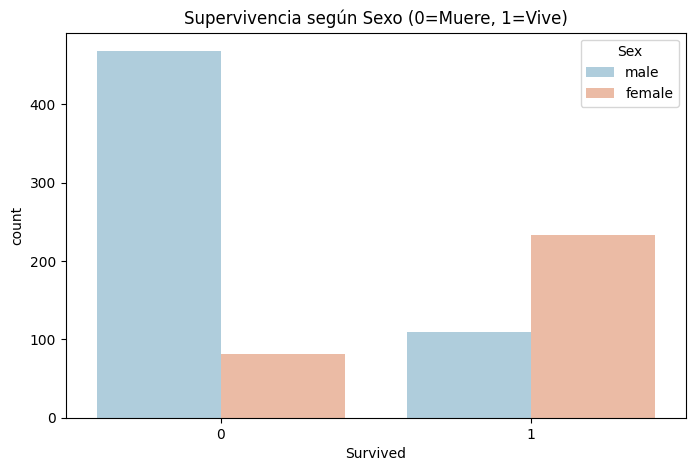

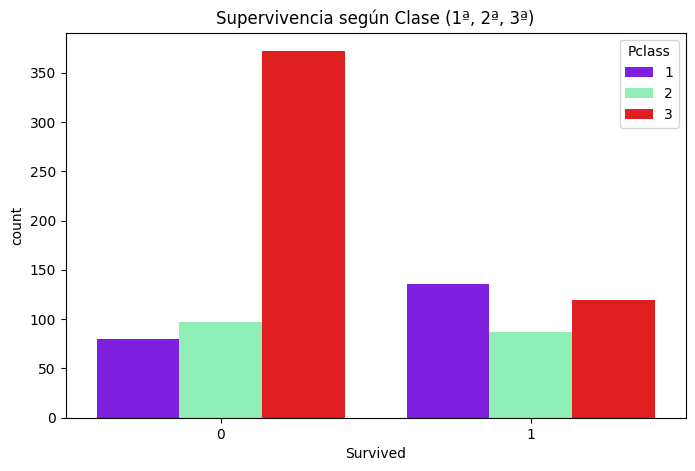

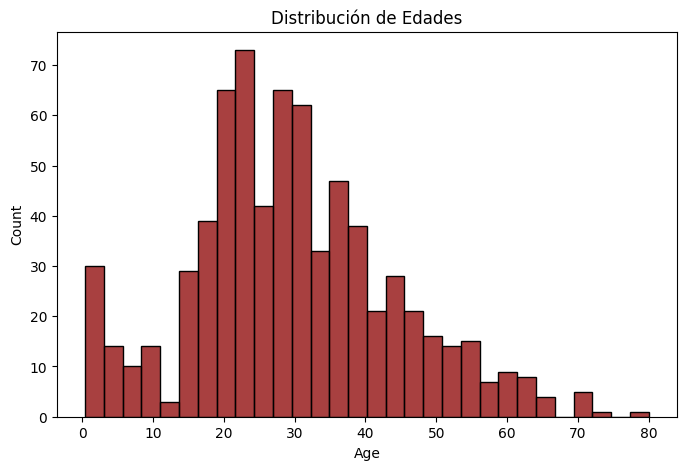

/tmp/ipykernel_19981/1961971271.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=train, palette='winter')


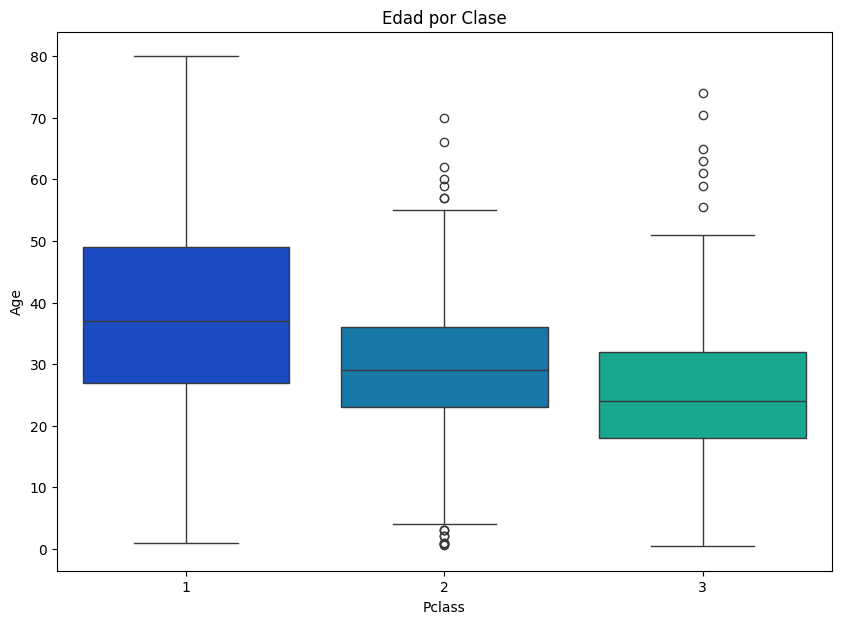

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CARGA ---
train = pd.read_csv('titanic_train.csv')

# --- 2. VISUAL EDA ---

# A. ¿Patrón de supervivencia basado en el SEXO?
# Copiamos la línea exacta que pedía el ejercicio
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')
plt.title('Supervivencia según Sexo (0=Muere, 1=Vive)')
plt.show()

# B. ¿Patrón basado en la CLASE (Pclass)?
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Pclass', data=train, palette='rainbow')
plt.title('Supervivencia según Clase (1ª, 2ª, 3ª)')
plt.show()

# C. Histograma de EDAD
plt.figure(figsize=(8, 5))
sns.histplot(train['Age'].dropna(), kde=False, color='darkred', bins=30)
plt.title('Distribución de Edades')
plt.show()

# D. Contraste Clase vs Edad (Boxplot)
plt.figure(figsize=(10, 7))
sns.boxplot(x='Pclass', y='Age', data=train, palette='winter')
plt.title('Edad por Clase')
plt.show()

----------------------------------



Rellenar los valores nulos de edad con la media

In [44]:
df_titanic['Age'].fillna(df_titanic['Age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

---------
Suprimir columnas innecesarias
Cabin tiene muchos nulos y creo que name, ticket, passager id no creyo que influya mucho

In [45]:


df_titanic.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)
df_titanic.dropna(inplace=True)



---------
VARIABLES DUMMIES -> convertir datos categóricos

In [46]:

# el drop_first=True borra la columna repetida y asi nos aseguramos que solo hay una colom con solo saber que t or false en mujer ya sabes qe sexo es
# sex = pd.get_dummies(df_titanic['Sex'], drop_first=True)
# embark = pd.get_dummies(df_titanic['Embarked'], drop_first=True)

# # ahora la añadimos la col
# df_titanic = pd.concat([df_titanic, sex, embark], axis=1)

# # Borramos las columnas de texto originales que ya no sirven
# df_titanic.drop(['Sex', 'Embarked'], axis=1, inplace=True)

# df_titanic.isnull().sum()

df_dummies = pd.get_dummies(data=df_titanic)
df_dummies.shape

(712, 11)

In [47]:
df_dummies.sample(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
38,0,3,18.0,2,0,18.0000,True,False,False,False,True
164,0,3,1.0,4,1,39.6875,False,True,False,False,True
307,1,1,17.0,1,0,108.9000,True,False,True,False,False
172,1,3,1.0,1,1,11.1333,True,False,False,False,True
387,1,2,36.0,0,0,13.0000,True,False,False,False,True
346,1,2,40.0,0,0,13.0000,True,False,False,False,True
813,0,3,6.0,4,2,31.2750,True,False,False,False,True
380,1,1,42.0,0,0,227.5250,True,False,True,False,False
746,0,3,16.0,1,1,20.2500,False,True,False,False,True
290,1,1,26.0,0,0,78.8500,True,False,False,False,True


-----------

Antes de crear el modelo de regresion logistica tenemos que dividir el dataset , siempre aorcadrse de no pasrle el target que es lo que quiere predecir 

In [48]:
# tenemos que dividir el dataset 
from sklearn.model_selection import train_test_split
X = df_dummies.drop('Survived',axis=1)
y = df_dummies['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


In [49]:
print("Training set shape",X_train.shape)
print("Test set shape",X_test.shape)

Training set shape (498, 10)
Test set shape (214, 10)


--------
creacion del modelo:D

In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

tree_clf = DecisionTreeClassifier(max_depth=7,)

In [74]:
tree_clf.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [75]:
from sklearn.tree import export_graphviz

In [71]:
# n_features= tree_clf.feature_names_in_
export_graphviz(
    tree_clf,                     # modelo entrenado
    out_file='titanic.dot',       # nombre del archivo que va a crear
    # feature_names=df_dummies # nombres de las columnas X
    class_names=['Fallece', 'Sobrevive'], # Qué significa 0 y 1
    rounded=True,
    filled=True
)



In [76]:
! dot -Tpng titanic.dot -o titanic.png

![RegressionTree](titanic.png)

In [77]:
tree_clf.score(X_test,y_test)

0.8644859813084113

In [80]:

nicki_pasajero = pd.DataFrame({
    'Pclass': [2],         
    'Age': [21],           
    'SibSp': [0],         
    'Parch': [0],         
    'Fare': [7.25],        
    
    
    'Sex_male': [0],      
    'Sex_female': [1],   
    
    'Embarked_Q': [0],     
    'Embarked_S': [1],    
    'Embarked_C': [0]      
})

nuevo_pasajero = nicki_pasajero[tree_clf.feature_names_in_]
prediccion = tree_clf.predict(nuevo_pasajero)
print("Predicción:", "Sobrevive 🚢" if prediccion[0] == 1 else "Fallece ☠️")

Predicción: Sobrevive 🚢


In [ ]:
# from sklearn.metrics import accuracy_score, f1_score
# tendria q hacer en el mismo lugar para asi hgacer las comparaciones y esi
# # 1. Obtenemos las predicciones de ambos
# pred_logistica = logmodel.predict(X_test)
# pred_arbol = tree_clf.predict(X_test)

# # 2. Calculamos las notas
# acc_log = accuracy_score(y_test, pred_logistica)
# acc_tree = accuracy_score(y_test, pred_arbol)

# # 3. Imprimimos el veredicto
# print(f"--- RESULTADOS FINALES ---")
# print(f"Regresión Logística: {acc_log:.2%} de acierto")
# print(f"Árbol de Decisión:   {acc_tree:.2%} de acierto")

# print("\n--- EL VEREDICTO ---")
# if acc_log > acc_tree:
#     print("Regresión Logística (Es más robusto para este caso)")
# elif acc_tree > acc_log:
#     print("Árbol de Decisión (Encontró patrones no lineales)")
# else:
#     print(!EMPATE TÉCNICO")

------
Ahora con random forest

In [ ]:
from sklearn.tree import export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree

In [82]:
crf = RandomForestClassifier(n_estimators=100, criterion='gini', max_features='sqrt' , max_samples=None, random_state=2)

In [83]:
crf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


AttributeError: 'DataFrame' object has no attribute 'feature_names'

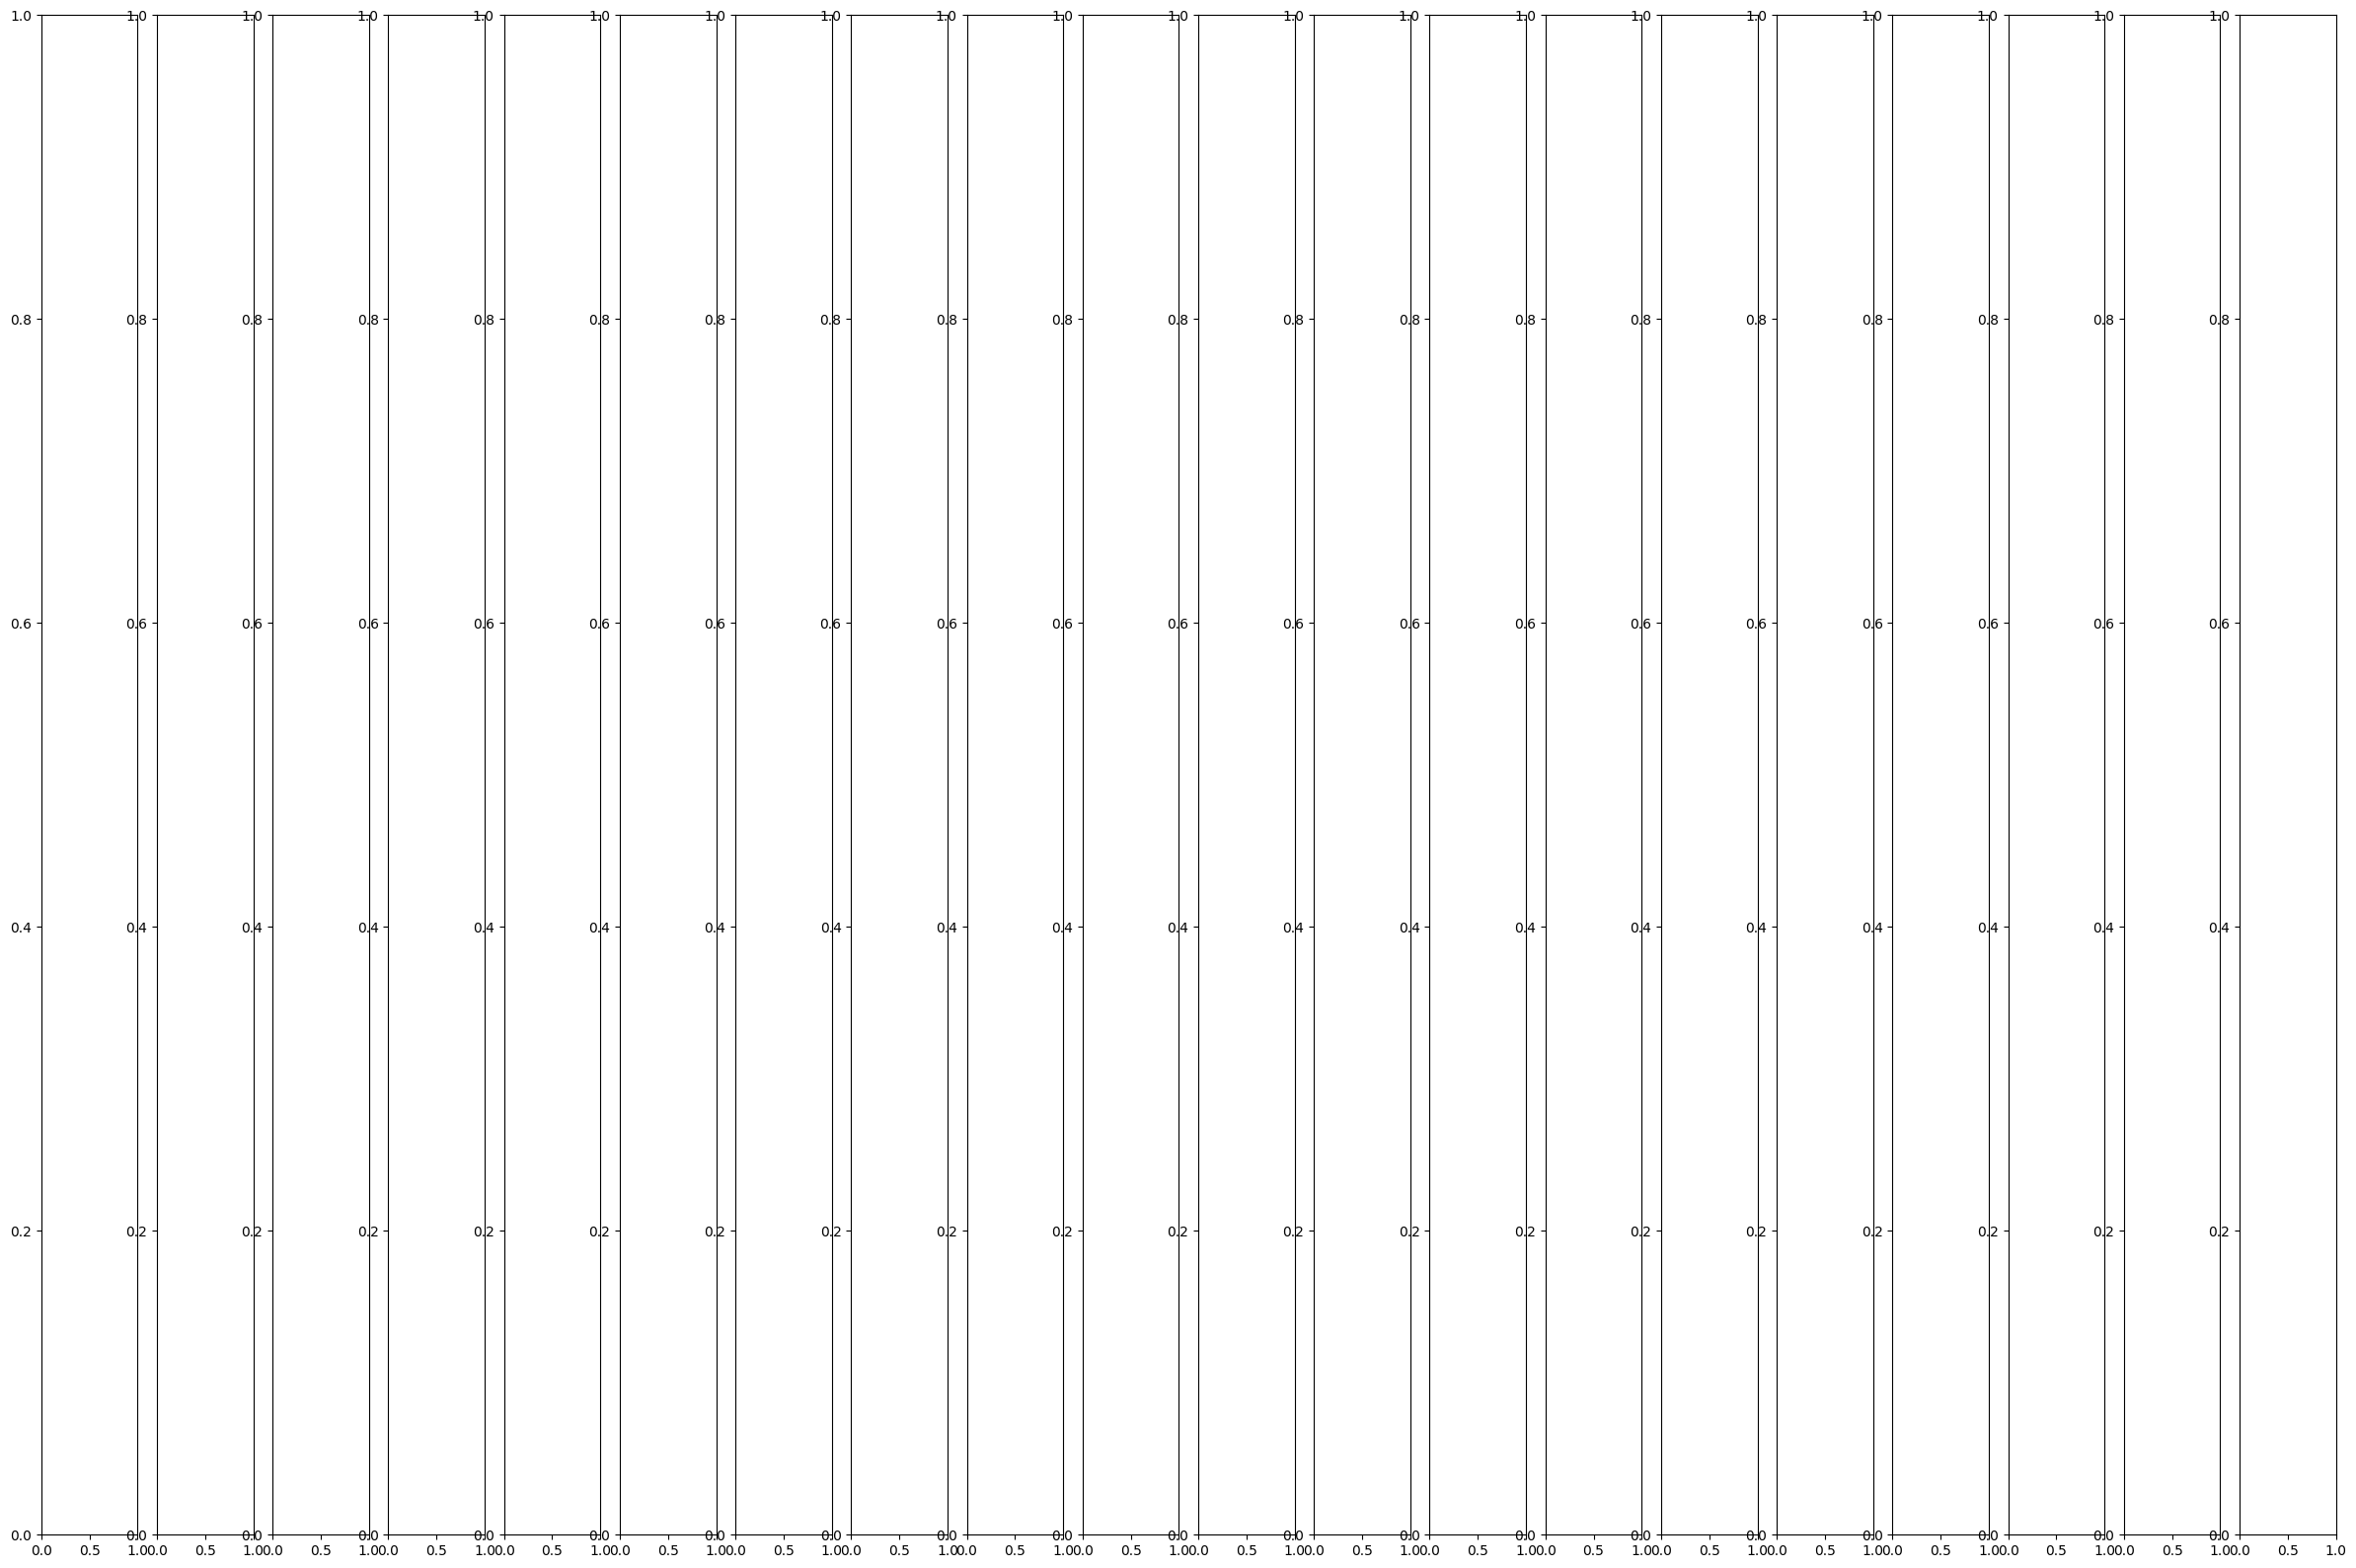

<Figure size 640x480 with 0 Axes>

In [85]:
fig, axes = plt.subplots(1,20,figsize=(30,20))

for i in range(len(axes)):
    fig = plt.figure()
    plot_tree(crf.estimators_[i],
            feature_names=df_titanic.feature_names,
            class_names=df_titanic.target_names,
            filled=True,
            impurity=True,
            rounded=True,
            ax=axes[i])
plt.show()